In [30]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
from tensorflow.keras.utils import to_categorical # 분류분석시 원핫인코딩
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input
import numpy as np

# 머신러닝/딥러닝 : 데이터의 법칙성을 추출
- 다양한 분야에서 응용 : 글씨 인식, 문장 분류, 질병 진단, 얼굴 인식.
** ML/DL의 종류
- 지도학습(독립=입력변수와 종속=타겟=출력변수가 모두 주어졌을 경우)
    회귀분석(타겟변수가 연속형일 때) vs 분류분석(multi, binary)
- 비지도학습(입력변수만)
    군집분석(clustering ; 군집화)
- 강화학습

** 지도학습에서의 ML, DL 프로그래밍 방식
1. 데이터 셋 확보(input입력변수, output종속변수)
    원본 데이터 및 시뮬레이션을 통해 데이터 생성
2. 전처리
    스케일 조정
    훈련 데이터 + 시험 데이터 + 검증 데이터 = 6:2:2 / 7:2:1 등
    학습 및 평가 가능한 포맷으로 변환(2차원 numpy, DataFrame)
3. 모델 구성
    model = Sequential() 객체 생성 후 필요한 층을 add()함수로 Dense 추가
4. 모델 학습 과정 설정 
    compile() 함수 이용, loss손실함수, optimizer, metrics평가지표 설정 => 평가지표 종류 많으나 당분간 acc(정확도)만 사용
5. 모델 학습(학습 과정 확인하기)
    model.fit(input, output, epoch) - 훈련셋입력=독립변수, 훈련셋타겟=종속변수, epoch=학습회수, 검증셋
6. 모델 평가
    테스트(시험) 데이터셋을 인자로 넣은 evaluate()함수 이용, 그래프
7. 모델 사용
    model.predict() 이용. 입력데이터는 2차원
8. 모델 저장
    save()함수 이용해서 저장. 저장된 모델은 load_model()함수를 이용해서 불러올 수 있음

# 1. 데이터셋 생성
# 2. 데이터 전처리

In [3]:
# 학습데이터 = 훈련 데이터
x_train = np.array([1,2,3,4,5,6,7,8,9]*10) 
y_train = np.array([2,4,6,8,10,12,14,16,18]*10) # 그룹 10종
# 검증데이터
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,4,6,8,10,12,14,16,18])
# 시험데이터 = 테스트셋
x_test = np.array([1,2,3,4,5,6,7,8,9])
y_test = np.array([2,4,6,8,10,12,14,16,18])
x_train.shape, x_val.shape, x_test.shape,y_train.shape, y_val.shape, y_test.shape,

((90,), (9,), (9,), (90,), (9,), (9,))

In [4]:
# 인코딩 종류
data = np.array(['a','b','c','d'])
print('원 데이터 :',data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le.fit(data)
# labeled_data = le.transform(data)
labeled_data = le.fit_transform(data)
print('라벨인코딩된 데이터 :',labeled_data)
one_hot_encoded_data = to_categorical(labeled_data)
print('원핫인코딩 된 데이터 :',one_hot_encoded_data)

원 데이터 : ['a' 'b' 'c' 'd']
라벨인코딩된 데이터 : [0 1 2 3]
원핫인코딩 된 데이터 : [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [5]:
# 분류분석을 하기 위해 target을 원핫인코딩(라벨링전환)
data = np.array([1,2,2,4,2])
print(data)
categorical_one_hot = to_categorical(data)
print('to_categorical을 이용한 원핫인코딩 :\n',categorical_one_hot)
import pandas as pd
get_dumies_one_hot = pd.get_dummies(data)
display('get_dummies를 이용한 원핫인코딩 :',get_dumies_one_hot)
print(type(categorical_one_hot))
print(type(get_dumies_one_hot))

[1 2 2 4 2]
to_categorical을 이용한 원핫인코딩 :
 [[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]]


'get_dummies를 이용한 원핫인코딩 :'

,1,2,4
0,1,0,0
1,0,1,0
2,0,1,0
3,0,0,1
4,0,1,0


<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>


In [6]:
# 분류분석을 위한 target변수 라벨링 전환 ( = 원핫인코딩 )
Y_train = to_categorical(y_train,19)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)

In [7]:
print('훈련셋 :',x_train.shape, Y_train.shape) # 독립변수 1개, 타겟변수 19개 입력 하나에 출력 19개, 타겟변수값의 총합은 1
print('검증셋 :',x_val.shape, Y_val.shape)
print('시험셋 :',x_test.shape, Y_test.shape)

훈련셋 : (90,) (90, 19)
검증셋 : (9,) (9, 19)
시험셋 : (9,) (9, 19)


# 3. 모델 구성하기

In [8]:
# 3. 모델 구성
model = Sequential()
model.add(Input(shape=(1,))) # 입력층
model.add(Dense(units=38, activation='sigmoid' ))  # units 출력수, activation 활성화 함수 : relu, tanh... 등
# 교안50p, 은닉층에서 값을 세분하게 나눴다가 합치는 게 맞출 확률이 높아짐
model.add(Dense(units=64, activation='elu' ))
model.add(Dense(units=32, activation='elu' ))
model.add(Dense(units=19, activation = 'softmax'))
# softmax : 모든 출력 결과의 합이 1. 분류분석 마지막 layer(출력층)에서 activation으로 사용

In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습과정 설정

In [10]:
model.compile(loss = 'categorical_crossentropy', # 분류분석에서 사용하는 손실함수(원핫인코딩 실시 후)
              optimizer = 'sgd', # sgd, gd, rmsprop, adam, nag ... => adam이랑 sgd 추천
              metrics=['accuracy']) # 평가지표 : accuracy 신뢰도

# 5. 모델 학습 시키기

In [11]:
hist = model.fit(x_train, Y_train, 
                 epochs=300, # 학습 회수 : 300번
                 batch_size = 10, # batch_size : 학습에 사용할 데이터의 규모 : 10개를 한번에 확인하고 가중치를 조정하겠다.
                 verbose=2, # 학습결과 출력 옵션 : 0 -> 출력없음, 1 -> 기본값, 2 -> epoch별 로그 메세지를 상세출력
                 validation_data = (x_val, Y_val)
                )

Epoch 1/300
9/9 - 1s - loss: 2.9462 - accuracy: 0.1111 - val_loss: 2.8518 - val_accuracy: 0.1111 - 909ms/epoch - 101ms/step
Epoch 2/300
9/9 - 0s - loss: 2.8161 - accuracy: 0.1111 - val_loss: 2.7492 - val_accuracy: 0.1111 - 53ms/epoch - 6ms/step
Epoch 3/300
9/9 - 0s - loss: 2.7246 - accuracy: 0.0889 - val_loss: 2.6745 - val_accuracy: 0.1111 - 45ms/epoch - 5ms/step
Epoch 4/300
9/9 - 0s - loss: 2.6569 - accuracy: 0.1444 - val_loss: 2.6152 - val_accuracy: 0.2222 - 34ms/epoch - 4ms/step
Epoch 5/300
9/9 - 0s - loss: 2.6042 - accuracy: 0.2000 - val_loss: 2.5650 - val_accuracy: 0.2222 - 56ms/epoch - 6ms/step
Epoch 6/300
9/9 - 0s - loss: 2.5603 - accuracy: 0.1222 - val_loss: 2.5225 - val_accuracy: 0.2222 - 52ms/epoch - 6ms/step
Epoch 7/300
9/9 - 0s - loss: 2.5219 - accuracy: 0.1556 - val_loss: 2.4854 - val_accuracy: 0.2222 - 49ms/epoch - 5ms/step
Epoch 8/300
9/9 - 0s - loss: 2.4850 - accuracy: 0.1889 - val_loss: 2.4526 - val_accuracy: 0.2222 - 47ms/epoch - 5ms/step
Epoch 9/300
9/9 - 0s - loss: 

Epoch 69/300
9/9 - 0s - loss: 1.6798 - accuracy: 0.3778 - val_loss: 1.6500 - val_accuracy: 0.4444 - 42ms/epoch - 5ms/step
Epoch 70/300
9/9 - 0s - loss: 1.6624 - accuracy: 0.3889 - val_loss: 1.6374 - val_accuracy: 0.4444 - 43ms/epoch - 5ms/step
Epoch 71/300
9/9 - 0s - loss: 1.6512 - accuracy: 0.3333 - val_loss: 1.6258 - val_accuracy: 0.4444 - 43ms/epoch - 5ms/step
Epoch 72/300
9/9 - 0s - loss: 1.6454 - accuracy: 0.4000 - val_loss: 1.6142 - val_accuracy: 0.4444 - 46ms/epoch - 5ms/step
Epoch 73/300
9/9 - 0s - loss: 1.6357 - accuracy: 0.3000 - val_loss: 1.6027 - val_accuracy: 0.3333 - 44ms/epoch - 5ms/step
Epoch 74/300
9/9 - 0s - loss: 1.6156 - accuracy: 0.3111 - val_loss: 1.5914 - val_accuracy: 0.5556 - 40ms/epoch - 4ms/step
Epoch 75/300
9/9 - 0s - loss: 1.5977 - accuracy: 0.4333 - val_loss: 1.5800 - val_accuracy: 0.5556 - 46ms/epoch - 5ms/step
Epoch 76/300
9/9 - 0s - loss: 1.5936 - accuracy: 0.4111 - val_loss: 1.5688 - val_accuracy: 0.5556 - 46ms/epoch - 5ms/step
Epoch 77/300
9/9 - 0s - 

Epoch 136/300
9/9 - 0s - loss: 1.1233 - accuracy: 0.8111 - val_loss: 1.1000 - val_accuracy: 0.8889 - 41ms/epoch - 5ms/step
Epoch 137/300
9/9 - 0s - loss: 1.1232 - accuracy: 0.7222 - val_loss: 1.0905 - val_accuracy: 0.8889 - 44ms/epoch - 5ms/step
Epoch 138/300
9/9 - 0s - loss: 1.1108 - accuracy: 0.8000 - val_loss: 1.0878 - val_accuracy: 0.7778 - 44ms/epoch - 5ms/step
Epoch 139/300
9/9 - 0s - loss: 1.1200 - accuracy: 0.7333 - val_loss: 1.0787 - val_accuracy: 0.8889 - 46ms/epoch - 5ms/step
Epoch 140/300
9/9 - 0s - loss: 1.1038 - accuracy: 0.7222 - val_loss: 1.0771 - val_accuracy: 0.7778 - 42ms/epoch - 5ms/step
Epoch 141/300
9/9 - 0s - loss: 1.0887 - accuracy: 0.7889 - val_loss: 1.0672 - val_accuracy: 0.8889 - 42ms/epoch - 5ms/step
Epoch 142/300
9/9 - 0s - loss: 1.0855 - accuracy: 0.8000 - val_loss: 1.0629 - val_accuracy: 1.0000 - 42ms/epoch - 5ms/step
Epoch 143/300
9/9 - 0s - loss: 1.0886 - accuracy: 0.7889 - val_loss: 1.0580 - val_accuracy: 0.7778 - 49ms/epoch - 5ms/step
Epoch 144/300
9/

Epoch 203/300
9/9 - 0s - loss: 0.7887 - accuracy: 0.9444 - val_loss: 0.7712 - val_accuracy: 1.0000 - 43ms/epoch - 5ms/step
Epoch 204/300
9/9 - 0s - loss: 0.7985 - accuracy: 0.9111 - val_loss: 0.7695 - val_accuracy: 0.8889 - 44ms/epoch - 5ms/step
Epoch 205/300
9/9 - 0s - loss: 0.7904 - accuracy: 0.8556 - val_loss: 0.7675 - val_accuracy: 1.0000 - 44ms/epoch - 5ms/step
Epoch 206/300
9/9 - 0s - loss: 0.7885 - accuracy: 0.8778 - val_loss: 0.7623 - val_accuracy: 0.7778 - 48ms/epoch - 5ms/step
Epoch 207/300
9/9 - 0s - loss: 0.7836 - accuracy: 0.8444 - val_loss: 0.7539 - val_accuracy: 1.0000 - 44ms/epoch - 5ms/step
Epoch 208/300
9/9 - 0s - loss: 0.7780 - accuracy: 0.8667 - val_loss: 0.7542 - val_accuracy: 1.0000 - 46ms/epoch - 5ms/step
Epoch 209/300
9/9 - 0s - loss: 0.7849 - accuracy: 0.8333 - val_loss: 0.7506 - val_accuracy: 0.8889 - 39ms/epoch - 4ms/step
Epoch 210/300
9/9 - 0s - loss: 0.7785 - accuracy: 0.8000 - val_loss: 0.7425 - val_accuracy: 1.0000 - 46ms/epoch - 5ms/step
Epoch 211/300
9/

Epoch 270/300
9/9 - 0s - loss: 0.5820 - accuracy: 0.9000 - val_loss: 0.5552 - val_accuracy: 0.8889 - 55ms/epoch - 6ms/step
Epoch 271/300
9/9 - 0s - loss: 0.5800 - accuracy: 0.9000 - val_loss: 0.5414 - val_accuracy: 1.0000 - 47ms/epoch - 5ms/step
Epoch 272/300
9/9 - 0s - loss: 0.5791 - accuracy: 0.8556 - val_loss: 0.5386 - val_accuracy: 0.8889 - 41ms/epoch - 5ms/step
Epoch 273/300
9/9 - 0s - loss: 0.5447 - accuracy: 0.8889 - val_loss: 0.5362 - val_accuracy: 1.0000 - 41ms/epoch - 5ms/step
Epoch 274/300
9/9 - 0s - loss: 0.5374 - accuracy: 0.9222 - val_loss: 0.5374 - val_accuracy: 1.0000 - 42ms/epoch - 5ms/step
Epoch 275/300
9/9 - 0s - loss: 0.5537 - accuracy: 0.9444 - val_loss: 0.5428 - val_accuracy: 0.8889 - 42ms/epoch - 5ms/step
Epoch 276/300
9/9 - 0s - loss: 0.5763 - accuracy: 0.9111 - val_loss: 0.5205 - val_accuracy: 0.8889 - 43ms/epoch - 5ms/step
Epoch 277/300
9/9 - 0s - loss: 0.5518 - accuracy: 0.9444 - val_loss: 0.5229 - val_accuracy: 0.8889 - 45ms/epoch - 5ms/step
Epoch 278/300
9/

In [12]:
hist.history.keys() # trainset => 'loss', 'accuracy', val_set => 'val_loss', 'val_accuracy'

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

# 6. 모델 평가하기(모델 학습과정 살펴보고, evaluate)

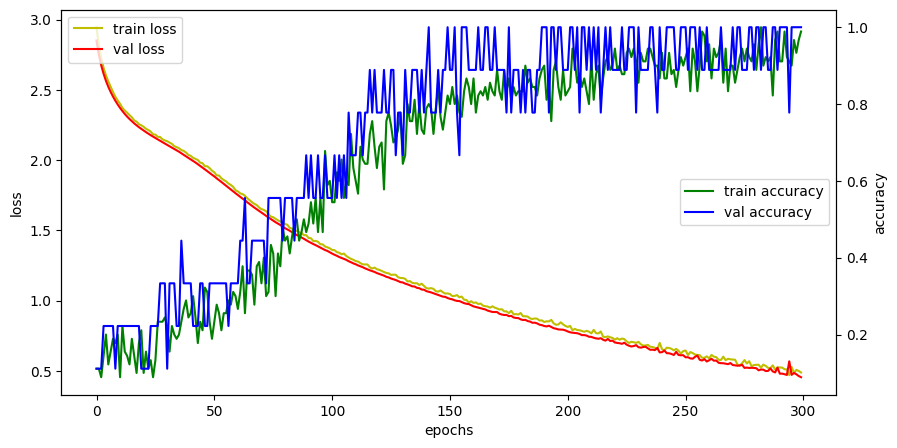

In [13]:
# 모델 학습과정 시각화
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history.get('loss'), label = 'train loss', color='y')
loss_ax.plot(hist.history.get('val_loss'), label = 'val loss', color='r')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')

acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history.get('accuracy'), label = 'train accuracy', color='g')
acc_ax.plot(hist.history.get('val_accuracy'), label = 'val accuracy', color='b')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc = 'upper left')
acc_ax.legend(loc = 'center right')

In [14]:
# 모델 평가하기
score = model.evaluate(x_test,Y_test, batch_size=1, verbose=2)

9/9 - 0s - loss: 0.4543 - accuracy: 1.0000 - 24ms/epoch - 3ms/step


In [15]:
score # loss, accuracy

[0.45427900552749634, 1.0]

In [16]:
print('평가된 loss :', score[0])
print('평가된 accuracy :', score[1]*100,'%')

평가된 loss : 0.45427900552749634
평가된 accuracy : 100.0 %


# 7. 모델 사용하기

In [17]:
H = model.predict(np.array([[2]]))
H

1/1 [==============================] - 0s 127ms/step


array([[7.1753111e-12, 2.4605849e-11, 1.1102761e-01, 2.7131960e-12,
        7.7347648e-01, 1.4544052e-10, 1.1443452e-01, 7.4009528e-11,
        1.0587400e-03, 1.7621749e-10, 2.6804209e-06, 2.0485799e-11,
        1.1070496e-08, 1.3235457e-11, 3.2467067e-12, 9.4649835e-12,
        6.7742852e-16, 8.8290382e-11, 8.9842135e-20]], dtype=float32)

In [18]:
# 분류분석의 예측은 predict결과를 argmax함수를 사용해서 활용
model.predict(np.array([[2]])).argmax()

1/1 [==============================] - 0s 25ms/step


4

In [19]:
# 4를 몇 % 확률로 예측했는지
H[0, H.argmax()] * 100

77.34764814376831

# 8. 모델 저장하기

In [20]:
# model.save('model/02_deep.h5')
from tensorflow.keras.models import save_model
save_model(model,'model/02_deep.h5')

## 저장된 모델 사용하기

In [21]:
import numpy as np

In [22]:
from tensorflow.keras.models import load_model
model2 = load_model('model/02_deep.h5')

In [23]:
model2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


In [24]:
data = np.array([[2], # 데이터가 몇 개든 2차원 데이터가 필요
                 [3]])
predictions = model2.predict(data)
predictions
predictions.argmax(axis=1) # 2차원 중 1차원의 각 구성요소 간 가장 큰 수가 있는 인덱스를 반환해라

1/1 [==============================] - 0s 83ms/step


array([4, 6], dtype=int64)

In [28]:
def predict_classes(model, data) :
    predictions = model.predict(data)
    return predictions.argmax(axis=-1)

In [26]:
import tensorflow as tf
# tensor 객체 : 차원을 가지고 있는 데이터 객체
# 조금 더 빠른 형태
@tf.function(reduce_retracing=True)
def predict_classes(model, data) :
    predictions = model(data, training=False)
    return tf.argmax(predictions, axis = -1)

In [29]:
input_data = int(input('어떤 데이터를 예측할까요?'))
data = np.array([[input_data]])
print('예측된 분류는',predict_classes(model2, data))

어떤 데이터를 예측할까요?5
1/1 [==============================] - 0s 19ms/step
예측된 분류는 [10]
